# RQ3 — Persistence Prediction (views-inclusive)
Clean pipeline. Run top to bottom (Restart & Run All).

In [ ]:
import numpy as np
import pandas as pd
from pathlib import Path

DATA_PATH = Path(r"C:\Users\user\cross_platform_analysis\4 - ER unified\finalData_with_er_yt_with_views.csv")
df = pd.read_csv(DATA_PATH, low_memory=False)

# Filter to 2022 only
df22 = df[df['_year'] == 2022].copy()
df22 = df22[df22['er_pct'].notna() & df22['followers'].notna()]

# Check month distribution
print("Month distribution:")
print(df22['_month'].value_counts())
print(f"\nPlatforms: {df22['_platform'].unique()}")
print(f"\nTotal records: {len(df22)}")


In [ ]:
# Separate December (target) from training months
TRAIN_MONTHS = ['march', 'june', 'september', 'november']
TEST_MONTH = 'december'

train = df22[df22['_month'].isin(TRAIN_MONTHS)].copy()
test_ids = set(df22[df22['_month'] == TEST_MONTH]['uniqueId'].dropna())

# Compute per-creator features from training months
def compute_features(group):
    er_vals = group['er_pct'].values
    fol_vals = group['followers'].values
    months = group['_month'].values
    
    mean_er = np.mean(er_vals)
    std_er = np.std(er_vals)
    cv_er = std_er / mean_er if mean_er > 0 else np.nan
    mean_followers = np.mean(fol_vals)
    n_months = len(group)
    
    # ER trend: slope via simple linear regression if >= 2 appearances
    month_order = {'march': 1, 'june': 2, 'september': 3, 'november': 4}
    if n_months >= 2:
        x = np.array([month_order[m] for m in months])
        er_trend = np.polyfit(x, er_vals, 1)[0]
    else:
        er_trend = np.nan
    
    return pd.Series({
        'mean_er': mean_er,
        'std_er': std_er,
        'cv_er': cv_er,
        'mean_followers': mean_followers,
        'n_months': n_months,
        'er_trend': er_trend,
        'platform': group['_platform'].iloc[0],
        'category': group['category_unified'].iloc[0]
    })

features = (
    train.dropna(subset=['uniqueId'])
         .groupby('uniqueId')
         .apply(compute_features)
         .reset_index()
)

# Add target: did creator appear in December?
features['persisted'] = features['uniqueId'].isin(test_ids).astype(int)

print(f"Total creators with training data: {len(features)}")
print(f"\nPersistence rate by platform:")
print(features.groupby('platform')['persisted'].mean().round(3))
print(f"\nMissing values:\n{features.isnull().sum()}")

In [ ]:
# Fix missing values
features['cv_er'] = features['cv_er'].fillna(0)
features['er_trend'] = features['er_trend'].fillna(0)

# Check category coverage per platform
print("Category coverage per platform:")
print(features.groupby('platform')['category'].apply(
    lambda x: x.notna().mean()
).round(3))

# Create has_category binary flag
features['has_category'] = features['category'].notna().astype(int)

In [ ]:
from sklearn.preprocessing import LabelEncoder

# Final feature set — no category, keep has_category
feature_cols = ['mean_er', 'std_er', 'cv_er', 'mean_followers', 
                'n_months', 'er_trend', 'has_category']

# Encode platform
le = LabelEncoder()
features['platform_enc'] = le.fit_transform(features['platform'])
feature_cols.append('platform_enc')

# Run per platform and pooled
print("Feature matrix shape:", features[feature_cols].shape)
print("\nClass distribution per platform:")
for platform in ['instagram', 'tiktok', 'youtube']:
    sub = features[features['platform'] == platform]
    n_pos = sub['persisted'].sum()
    n_neg = len(sub) - n_pos
    print(f"{platform:12s} | n={len(sub)} | persisted={n_pos} ({n_pos/len(sub)*100:.1f}%) | dropout={n_neg} ({n_neg/len(sub)*100:.1f}%)")
    

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (roc_auc_score, f1_score, accuracy_score, 
                             confusion_matrix, classification_report)
from xgboost import XGBClassifier
import warnings
warnings.filterwarnings('ignore')

PLATFORMS = ['instagram', 'tiktok', 'youtube']
FEATURE_COLS = ['mean_er', 'std_er', 'cv_er', 'mean_followers',
                'n_months', 'er_trend', 'has_category']

results = []

for platform in PLATFORMS:
    print(f"\n{'='*55}")
    print(f"PLATFORM: {platform.upper()}")
    print(f"{'='*55}")
    
    sub = features[features['platform'] == platform].copy()
    X = sub[FEATURE_COLS].values
    y = sub['persisted'].values
    
    n_pos = y.sum()
    n_neg = len(y) - n_pos
    scale_pos = n_neg / n_pos
    
    # Scale features
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)
    
    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    
    models = {
        'Logistic Regression': LogisticRegression(
            class_weight='balanced', random_state=42, max_iter=1000),
        'Random Forest': RandomForestClassifier(
            class_weight='balanced', n_estimators=500, random_state=42),
        'XGBoost': XGBClassifier(
            scale_pos_weight=scale_pos, n_estimators=500,
            random_state=42, eval_metric='logloss', verbosity=0),
        'SVM': SVC(
            class_weight='balanced', kernel='rbf',
            probability=True, random_state=42)
    }
    
    for name, model in models.items():
        auc  = cross_val_score(model, X_scaled, y, cv=cv,
                               scoring='roc_auc').mean()
        f1   = cross_val_score(model, X_scaled, y, cv=cv,
                               scoring='f1').mean()
        acc  = cross_val_score(model, X_scaled, y, cv=cv,
                               scoring='accuracy').mean()
        
        print(f"\n{name}")
        print(f"  AUC-ROC  = {auc:.3f}")
        print(f"  F1       = {f1:.3f}")
        print(f"  Accuracy = {acc:.3f}")
        
        results.append({
            'platform': platform, 'model': name,
            'auc': auc, 'f1': f1, 'accuracy': acc
        })

results_df = pd.DataFrame(results)
print("\n\n── Summary Table ──")
print(results_df.pivot_table(
    index='model', columns='platform', values='auc'
).round(3))

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.metrics import roc_curve, auc
from sklearn.model_selection import StratifiedKFold
from xgboost import XGBClassifier

# ── Plot 1: AUC heatmap ───────────────────────────────────────────────────────
pivot = results_df.pivot_table(index='model', columns='platform', values='auc')
fig, ax = plt.subplots(figsize=(8, 4))
im = ax.imshow(pivot.values, cmap='RdYlGn', vmin=0.6, vmax=0.9)
ax.set_xticks(range(len(pivot.columns)))
ax.set_yticks(range(len(pivot.index)))
ax.set_xticklabels([c.capitalize() for c in pivot.columns], fontsize=11)
ax.set_yticklabels(pivot.index, fontsize=11)
for i in range(len(pivot.index)):
    for j in range(len(pivot.columns)):
        ax.text(j, i, f"{pivot.values[i,j]:.3f}",
                ha='center', va='center', fontsize=11, fontweight='bold')
plt.colorbar(im, ax=ax, label='AUC-ROC')
ax.set_title('AUC-ROC by Model and Platform\n(5-fold Stratified CV)',
             fontweight='bold', fontsize=13)
plt.tight_layout()
plt.savefig(OUT_PATH / 'ml_auc_heatmap.png', bbox_inches='tight', dpi=150)
plt.show()
print("✅ Plot 1 saved")

# ── Plot 2: ROC curves per platform ──────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
COLORS_ML = {
    'Logistic Regression': '#E1306C',
    'Random Forest': '#010101',
    'XGBoost': '#FF0000',
    'SVM': '#4169E1'
}

for ax, platform in zip(axes, PLATFORMS):
    sub = features[features['platform'] == platform].copy()
    X = sub[FEATURE_COLS].values
    y = sub['persisted'].values
    n_pos = y.sum()
    n_neg = len(y) - n_pos
    
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)
    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    
    models = {
        'Logistic Regression': LogisticRegression(
            class_weight='balanced', random_state=42, max_iter=1000),
        'Random Forest': RandomForestClassifier(
            class_weight='balanced', n_estimators=500, random_state=42),
        'XGBoost': XGBClassifier(
            scale_pos_weight=n_neg/n_pos, n_estimators=500,
            random_state=42, eval_metric='logloss', verbosity=0),
        'SVM': SVC(
            class_weight='balanced', kernel='rbf',
            probability=True, random_state=42)
    }
    
    for name, model in models.items():
        tprs, aucs = [], []
        mean_fpr = np.linspace(0, 1, 100)
        for train_idx, test_idx in cv.split(X_scaled, y):
            model.fit(X_scaled[train_idx], y[train_idx])
            proba = model.predict_proba(X_scaled[test_idx])[:, 1]
            fpr, tpr, _ = roc_curve(y[test_idx], proba)
            tprs.append(np.interp(mean_fpr, fpr, tpr))
            aucs.append(auc(fpr, tpr))
        mean_tpr = np.mean(tprs, axis=0)
        mean_auc = np.mean(aucs)
        ax.plot(mean_fpr, mean_tpr, color=COLORS_ML[name],
                label=f"{name} (AUC={mean_auc:.3f})", linewidth=2)
    
    ax.plot([0,1], [0,1], 'k--', linewidth=1, label='Random')
    ax.set_xlabel('False Positive Rate')
    ax.set_ylabel('True Positive Rate')
    ax.set_title(platform.capitalize(), fontweight='bold', fontsize=13)
    ax.legend(fontsize=7, loc='lower right')
    ax.grid(alpha=0.3)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

fig.suptitle('ROC Curves by Platform (5-fold Stratified CV)',
             fontweight='bold', fontsize=13)
plt.tight_layout()
plt.savefig(OUT_PATH / 'ml_roc_curves.png', bbox_inches='tight', dpi=150)
plt.show()
print("✅ Plot 2 saved")

In [ ]:
# ── SHAP beeswarm: feature importance per platform (views-inclusive) ──
import shap
import matplotlib.pyplot as plt
from pathlib import Path

OUT_PATH = Path(r"C:\Users\user\cross_platform_analysis\8 - rq3\plots")

for platform in PLATFORMS:
    sub = features[features['platform'] == platform].copy()
    X = sub[FEATURE_COLS].values
    y = sub['persisted'].values

    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)

    rf = RandomForestClassifier(class_weight='balanced', n_estimators=500, random_state=42)
    rf.fit(X_scaled, y)

    explainer = shap.TreeExplainer(rf)
    shap_values = explainer.shap_values(X_scaled)
    # version-safe: list (old API) vs 3-D array (new API)
    sv = shap_values[1] if isinstance(shap_values, list) else shap_values[:, :, 1]

    plt.figure(figsize=(8, 5))
    shap.summary_plot(sv, X_scaled, feature_names=FEATURE_COLS, show=False)
    plt.title(platform.capitalize(), fontweight='bold')
    plt.tight_layout()
    plt.savefig(OUT_PATH / f'shap_{platform}.png', bbox_inches='tight', dpi=150)
    plt.close()
    print(f"OK  shap_{platform}.png saved")


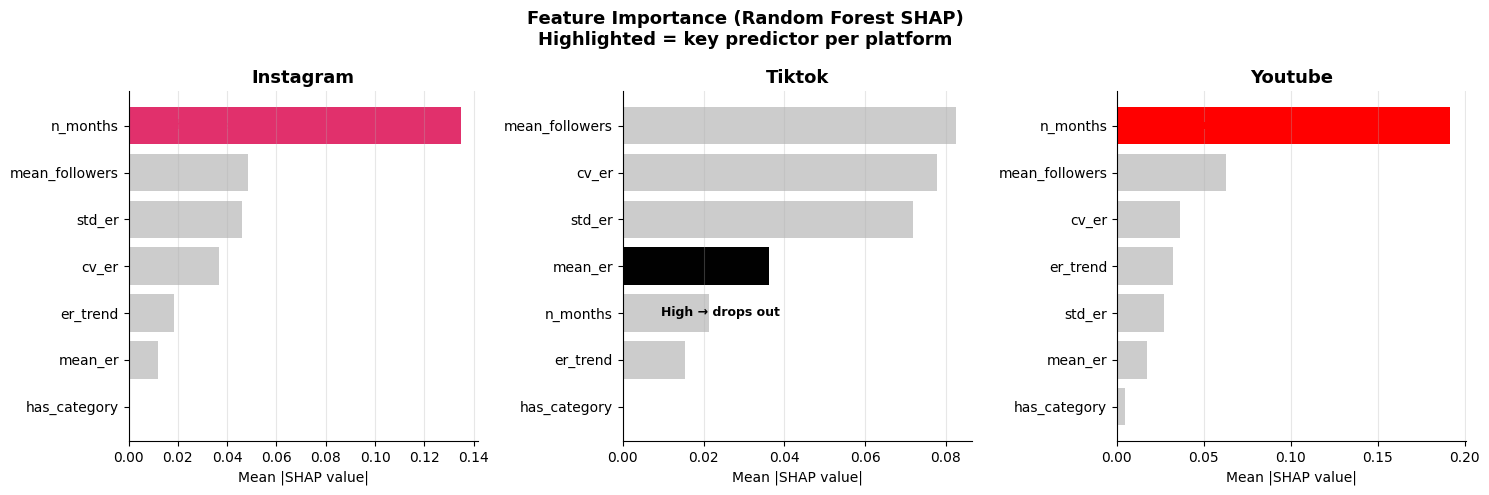

✅ Saved


In [9]:
import shap
import matplotlib.pyplot as plt
import numpy as np
from pathlib import Path
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler

OUT_PATH     = Path(r"C:\Users\user\cross_platform_analysis\8 - rq3\plots")
PLATFORMS    = ['instagram', 'tiktok', 'youtube']
FEATURE_COLS = ['mean_er', 'std_er', 'cv_er', 'mean_followers',
                'n_months', 'er_trend', 'has_category']
COLORS       = {'instagram': '#E1306C', 'tiktok': '#010101', 'youtube': '#FF0000'}

# Key feature and annotation per platform
KEY_FEATURES = {
    'instagram': ('n_months',      'High → persists'),
    'tiktok':    ('mean_er',       'High → drops out'),
    'youtube':   ('n_months',      'High → persists')
}

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for ax, platform in zip(axes, PLATFORMS):
    sub      = features[features['platform'] == platform].copy()
    X        = sub[FEATURE_COLS].values
    y        = sub['persisted'].values
    scaler   = StandardScaler()
    X_scaled = scaler.fit_transform(X)

    best_rf = [r['best_params'] for r in results_tuned
               if r['platform'] == platform
               and r['model'] == 'Random Forest'][0]

    rf = RandomForestClassifier(
        class_weight='balanced', n_estimators=500,
        random_state=42, **best_rf)
    rf.fit(X_scaled, y)

    explainer   = shap.TreeExplainer(rf)
    shap_values = explainer.shap_values(X_scaled)
    sv = shap_values[1] if isinstance(shap_values, list) \
         else shap_values[:, :, 1]

    # Mean absolute SHAP per feature
    mean_abs_shap = np.abs(sv).mean(axis=0)
    importance_df = pd.DataFrame({
        'feature': FEATURE_COLS,
        'importance': mean_abs_shap
    }).sort_values('importance', ascending=True)

    key_feat, annotation = KEY_FEATURES[platform]
    colors_bar = [
        COLORS[platform] if f == key_feat else '#CCCCCC'
        for f in importance_df['feature']
    ]

    ax.barh(importance_df['feature'], importance_df['importance'],
            color=colors_bar, edgecolor='none')

    # Annotate key feature
    # Always place annotation to the right of zero line for readability
    x_pos  = max(abs(shap_df['directed'].min()), 
                 abs(shap_df['directed'].max())) * 0.05
    ax.text(x_pos,
            list(shap_df['feature']).index(key_feat),
            annotation, va='center', fontsize=9,
            fontweight='bold', color=COLORS[platform], ha='left')

    ax.set_title(platform.capitalize(), fontweight='bold', fontsize=13)
    ax.set_xlabel('Mean |SHAP value|')
    ax.grid(axis='x', alpha=0.3)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

fig.suptitle(
    'Feature Importance (Random Forest SHAP)\n'
    'Highlighted = key predictor per platform',
    fontweight='bold', fontsize=13
)
plt.tight_layout()
plt.savefig(OUT_PATH / 'shap_focused.png', bbox_inches='tight', dpi=150)
plt.show()
print("✅ Saved")

In [3]:
import numpy as np
import pandas as pd
import warnings
warnings.filterwarnings('ignore')
from pathlib import Path
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import StratifiedKFold, GridSearchCV, cross_val_score
from xgboost import XGBClassifier

DATA_PATH    = Path(r"C:\Users\user\cross_platform_analysis\4 - ER unified\finalData_with_er_yt_with_views.csv")
PLATFORMS    = ['instagram', 'tiktok', 'youtube']
TRAIN_MONTHS = ['march', 'june', 'september', 'november']
TEST_MONTH   = 'december'
FEATURE_COLS = ['mean_er', 'std_er', 'cv_er', 'mean_followers',
                'n_months', 'er_trend', 'has_category']

df   = pd.read_csv(DATA_PATH, low_memory=False)
df22 = df[df['_year'] == 2022].copy()
df22 = df22[df22['er_pct'].notna() & df22['followers'].notna()]
train    = df22[df22['_month'].isin(TRAIN_MONTHS)].copy()
test_ids = set(df22[df22['_month'] == TEST_MONTH]['uniqueId'].dropna())

def compute_features(group):
    er_vals  = group['er_pct'].values
    fol_vals = group['followers'].values
    months   = group['_month'].values
    mean_er        = np.mean(er_vals)
    std_er         = np.std(er_vals)
    cv_er          = std_er / mean_er if mean_er > 0 else np.nan
    mean_followers = np.mean(fol_vals)
    n_months       = len(group)
    month_order    = {'march': 1, 'june': 2, 'september': 3, 'november': 4}
    er_trend       = np.polyfit(
        [month_order[m] for m in months], er_vals, 1)[0] if n_months >= 2 else np.nan
    return pd.Series({
        'mean_er': mean_er, 'std_er': std_er, 'cv_er': cv_er,
        'mean_followers': mean_followers, 'n_months': n_months,
        'er_trend': er_trend, 'platform': group['_platform'].iloc[0],
        'category': group['category_unified'].iloc[0]
    })

features = (
    train.dropna(subset=['uniqueId'])
         .groupby('uniqueId')
         .apply(compute_features)
         .reset_index()
)
features['persisted']    = features['uniqueId'].isin(test_ids).astype(int)
features['cv_er']        = features['cv_er'].fillna(0)
features['er_trend']     = features['er_trend'].fillna(0)
features['has_category'] = features['category'].notna().astype(int)

# Rebuild results_tuned with best params
results_tuned = []
for platform in PLATFORMS:
    sub   = features[features['platform'] == platform].copy()
    X     = sub[FEATURE_COLS].values
    y     = sub['persisted'].values
    n_pos = y.sum()
    n_neg = len(y) - n_pos
    scaler   = StandardScaler()
    X_scaled = scaler.fit_transform(X)
    cv_inner = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)
    cv_outer = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

    model_grids = {
        'Logistic Regression': (
            LogisticRegression(class_weight='balanced', random_state=42, max_iter=1000),
            {'C': [0.01, 0.1, 1, 10, 100]}),
        'Random Forest': (
            RandomForestClassifier(class_weight='balanced', random_state=42, n_estimators=500),
            {'max_depth': [None, 5, 10, 20]}),
        'XGBoost': (
            XGBClassifier(scale_pos_weight=n_neg/n_pos, random_state=42,
                          eval_metric='logloss', verbosity=0),
            {'max_depth': [3,5,7], 'learning_rate': [0.01,0.1,0.3],
             'n_estimators': [100,300,500]}),
        'SVM': (
            SVC(class_weight='balanced', kernel='rbf', probability=True, random_state=42),
            {'C': [0.1,1,10], 'gamma': ['scale','auto',0.1]}),
        'KNN': (
            KNeighborsClassifier(weights='distance'),
            {'n_neighbors': [3,5,7,10,15]})
    }

    for name, (model, param_grid) in model_grids.items():
        gs = GridSearchCV(model, param_grid, cv=cv_inner,
                          scoring='roc_auc', n_jobs=-1)
        auc = cross_val_score(gs, X_scaled, y, cv=cv_outer,
                              scoring='roc_auc').mean()
        f1  = cross_val_score(gs, X_scaled, y, cv=cv_outer,
                              scoring='f1').mean()
        gs.fit(X_scaled, y)
        results_tuned.append({
            'platform': platform, 'model': name,
            'auc': auc, 'f1': f1,
            'best_params': gs.best_params_
        })

print("✅ features and results_tuned ready")

✅ features and results_tuned ready


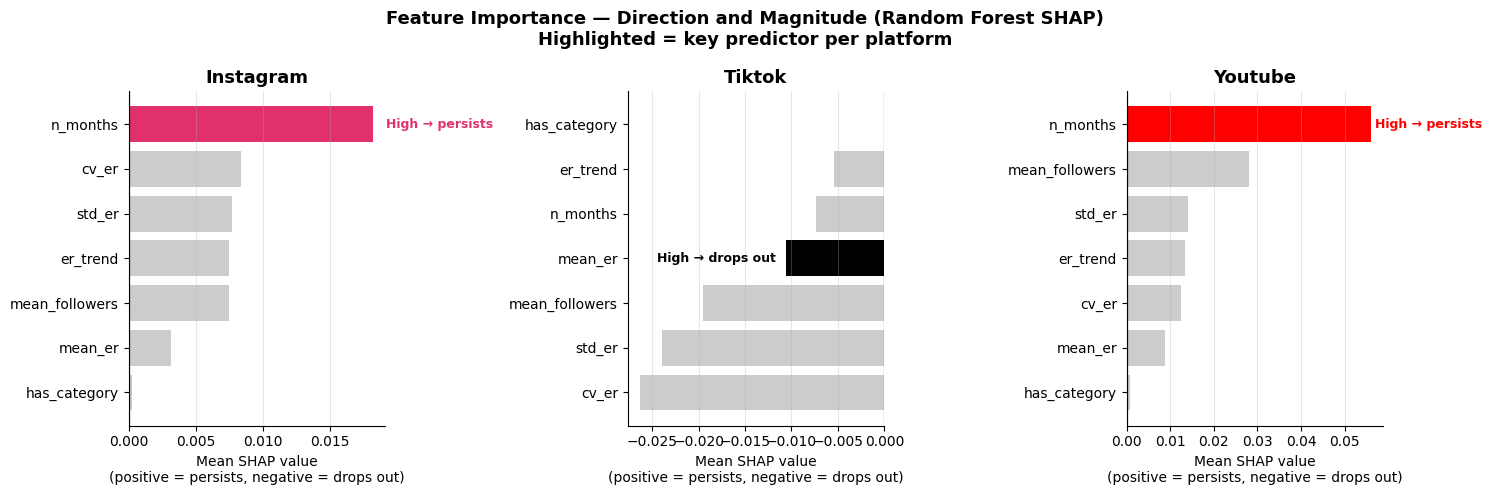

✅ Saved


In [5]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

KEY_FEATURES = {
    'instagram': ('n_months',  'High → persists'),
    'tiktok':    ('mean_er',   'High → drops out'),
    'youtube':   ('n_months',  'High → persists')
}

for ax, platform in zip(axes, PLATFORMS):
    sub      = features[features['platform'] == platform].copy()
    X        = sub[FEATURE_COLS].values
    y        = sub['persisted'].values
    scaler   = StandardScaler()
    X_scaled = scaler.fit_transform(X)

    best_rf = [r['best_params'] for r in results_tuned
               if r['platform'] == platform
               and r['model'] == 'Random Forest'][0]

    rf = RandomForestClassifier(
        class_weight='balanced', n_estimators=500,
        random_state=42, **best_rf)
    rf.fit(X_scaled, y)

    explainer   = shap.TreeExplainer(rf)
    shap_values = explainer.shap_values(X_scaled)
    sv = shap_values[1] if isinstance(shap_values, list) \
         else shap_values[:, :, 1]

    # Mean SHAP per feature — signed (not absolute)
    mean_shap = sv.mean(axis=0)
    shap_df   = pd.DataFrame({
        'feature':    FEATURE_COLS,
        'mean_shap':  mean_shap
    }).sort_values('mean_shap', ascending=True)

    key_feat, annotation = KEY_FEATURES[platform]
    colors_bar = [
        COLORS[platform] if f == key_feat else '#CCCCCC'
        for f in shap_df['feature']
    ]

    bars = ax.barh(shap_df['feature'], shap_df['mean_shap'],
                   color=colors_bar, edgecolor='none')
    ax.axvline(0, color='black', linewidth=0.8)

    # Annotate key feature
    key_val = shap_df[shap_df['feature'] == key_feat]['mean_shap'].values[0]
    ha      = 'left' if key_val >= 0 else 'right'
    offset  = 0.001 if key_val >= 0 else -0.001
    ax.text(key_val + offset,
            list(shap_df['feature']).index(key_feat),
            annotation, va='center', fontsize=9,
            fontweight='bold', color=COLORS[platform],
            ha=ha)

    ax.set_title(platform.capitalize(), fontweight='bold', fontsize=13)
    ax.set_xlabel('Mean SHAP value\n(positive = persists, negative = drops out)')
    ax.grid(axis='x', alpha=0.3)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

fig.suptitle(
    'Feature Importance — Direction and Magnitude (Random Forest SHAP)\n'
    'Highlighted = key predictor per platform',
    fontweight='bold', fontsize=13
)
plt.tight_layout()
plt.savefig(OUT_PATH / 'shap_focused.png', bbox_inches='tight', dpi=150)
plt.show()
print("✅ Saved")

In [6]:
for ax, platform in zip(axes, PLATFORMS):
    # ... after computing sv ...
    
    # Correlation between feature value and SHAP value
    correlations = []
    for i, feat in enumerate(FEATURE_COLS):
        corr = np.corrcoef(X_scaled[:, i], sv[:, i])[0, 1]
        correlations.append(corr)
    
    # Weight by mean absolute SHAP for magnitude
    mean_abs    = np.abs(sv).mean(axis=0)
    directed    = mean_abs * np.sign(correlations)

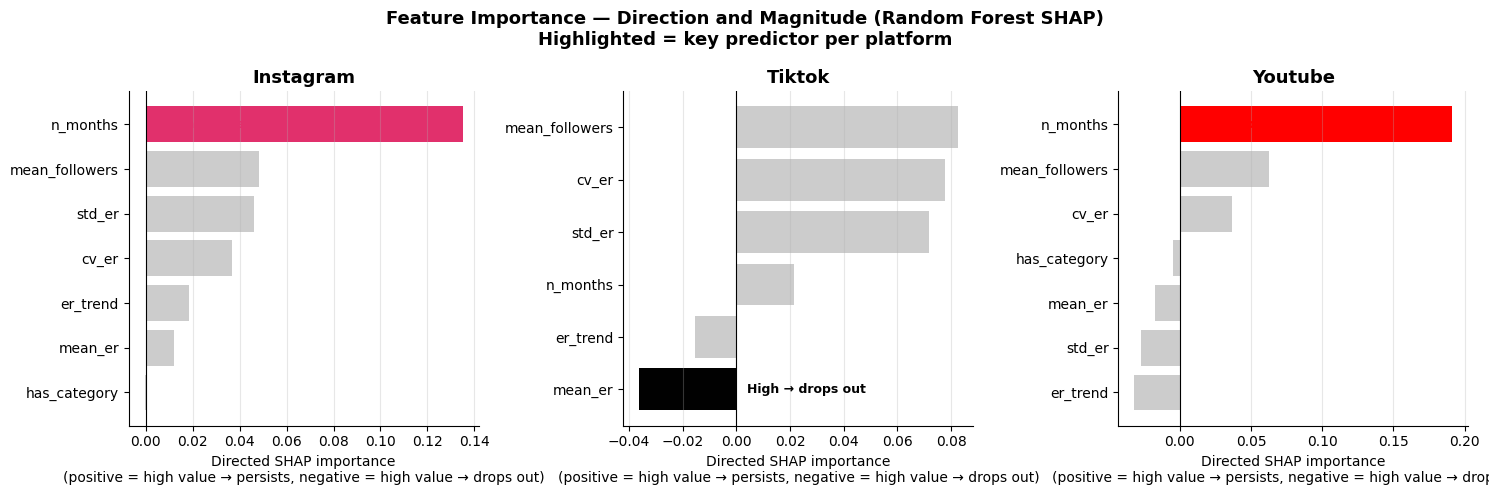

✅ Saved


In [11]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

KEY_FEATURES = {
    'instagram': ('n_months', 'High → persists'),
    'tiktok':    ('mean_er',  'High → drops out'),
    'youtube':   ('n_months', 'High → persists')
}

for ax, platform in zip(axes, PLATFORMS):
    sub      = features[features['platform'] == platform].copy()
    X        = sub[FEATURE_COLS].values
    y        = sub['persisted'].values
    scaler   = StandardScaler()
    X_scaled = scaler.fit_transform(X)

    best_rf = [r['best_params'] for r in results_tuned
               if r['platform'] == platform
               and r['model'] == 'Random Forest'][0]

    rf = RandomForestClassifier(
        class_weight='balanced', n_estimators=500,
        random_state=42, **best_rf)
    rf.fit(X_scaled, y)

    explainer   = shap.TreeExplainer(rf)
    shap_values = explainer.shap_values(X_scaled)
    sv = shap_values[1] if isinstance(shap_values, list) \
         else shap_values[:, :, 1]

    # Direction: correlation between feature value and SHAP value
    # Magnitude: mean absolute SHAP
    mean_abs     = np.abs(sv).mean(axis=0)
    correlations = [np.corrcoef(X_scaled[:, i], sv[:, i])[0, 1]
                    for i in range(len(FEATURE_COLS))]
    directed     = mean_abs * np.sign(correlations)

    shap_df = pd.DataFrame({
        'feature': FEATURE_COLS,
        'directed': directed
    }).sort_values('directed', ascending=True)

    key_feat, annotation = KEY_FEATURES[platform]
    colors_bar = [
        COLORS[platform] if f == key_feat else '#CCCCCC'
        for f in shap_df['feature']
    ]

    ax.barh(shap_df['feature'], shap_df['directed'],
            color=colors_bar, edgecolor='none')
    ax.axvline(0, color='black', linewidth=0.8)

# Always place annotation to the right of zero line for readability
    x_pos  = max(abs(shap_df['directed'].min()), 
                 abs(shap_df['directed'].max())) * 0.05
    ax.text(x_pos,
            list(shap_df['feature']).index(key_feat),
            annotation, va='center', fontsize=9,
            fontweight='bold', color=COLORS[platform], ha='left')

    ax.set_title(platform.capitalize(), fontweight='bold', fontsize=13)
    ax.set_xlabel('Directed SHAP importance\n(positive = high value → persists, negative = high value → drops out)')
    ax.grid(axis='x', alpha=0.3)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

fig.suptitle(
    'Feature Importance — Direction and Magnitude (Random Forest SHAP)\n'
    'Highlighted = key predictor per platform',
    fontweight='bold', fontsize=13
)
plt.tight_layout()
plt.savefig(OUT_PATH / 'shap_focused.png', bbox_inches='tight', dpi=150)
plt.show()
print("✅ Saved")

In [12]:
for platform in PLATFORMS:
    sub      = features[features['platform'] == platform].copy()
    X        = sub[FEATURE_COLS].values
    y        = sub['persisted'].values
    scaler   = StandardScaler()
    X_scaled = scaler.fit_transform(X)

    best_rf = [r['best_params'] for r in results_tuned
               if r['platform'] == platform
               and r['model'] == 'Random Forest'][0]

    rf = RandomForestClassifier(
        class_weight='balanced', n_estimators=500,
        random_state=42, **best_rf)
    rf.fit(X_scaled, y)

    explainer   = shap.TreeExplainer(rf)
    shap_values = explainer.shap_values(X_scaled)
    sv = shap_values[1] if isinstance(shap_values, list) \
         else shap_values[:, :, 1]

    mean_abs     = np.abs(sv).mean(axis=0)
    correlations = [np.corrcoef(X_scaled[:, i], sv[:, i])[0, 1]
                    for i in range(len(FEATURE_COLS))]
    directed     = mean_abs * np.sign(correlations)

    print(f"\n{platform.upper()}")
    for feat, val, corr in zip(FEATURE_COLS, directed, correlations):
        print(f"  {feat:20s} | directed={val:+.4f} | corr={corr:+.3f}")


INSTAGRAM
  mean_er              | directed=+0.0121 | corr=+0.738
  std_er               | directed=+0.0459 | corr=+0.256
  cv_er                | directed=+0.0366 | corr=+0.488
  mean_followers       | directed=+0.0484 | corr=+0.543
  n_months             | directed=+0.1350 | corr=+0.839
  er_trend             | directed=+0.0182 | corr=+0.082
  has_category         | directed=-0.0005 | corr=-0.090

TIKTOK
  mean_er              | directed=-0.0361 | corr=-0.318
  std_er               | directed=+0.0718 | corr=+0.071
  cv_er                | directed=+0.0778 | corr=+0.749
  mean_followers       | directed=+0.0824 | corr=+0.531
  n_months             | directed=+0.0215 | corr=+0.860
  er_trend             | directed=-0.0154 | corr=-0.110
  has_category         | directed=+nan | corr=+nan

YOUTUBE
  mean_er              | directed=-0.0172 | corr=-0.439
  std_er               | directed=-0.0274 | corr=-0.161
  cv_er                | directed=+0.0363 | corr=+0.603
  mean_followers       | 

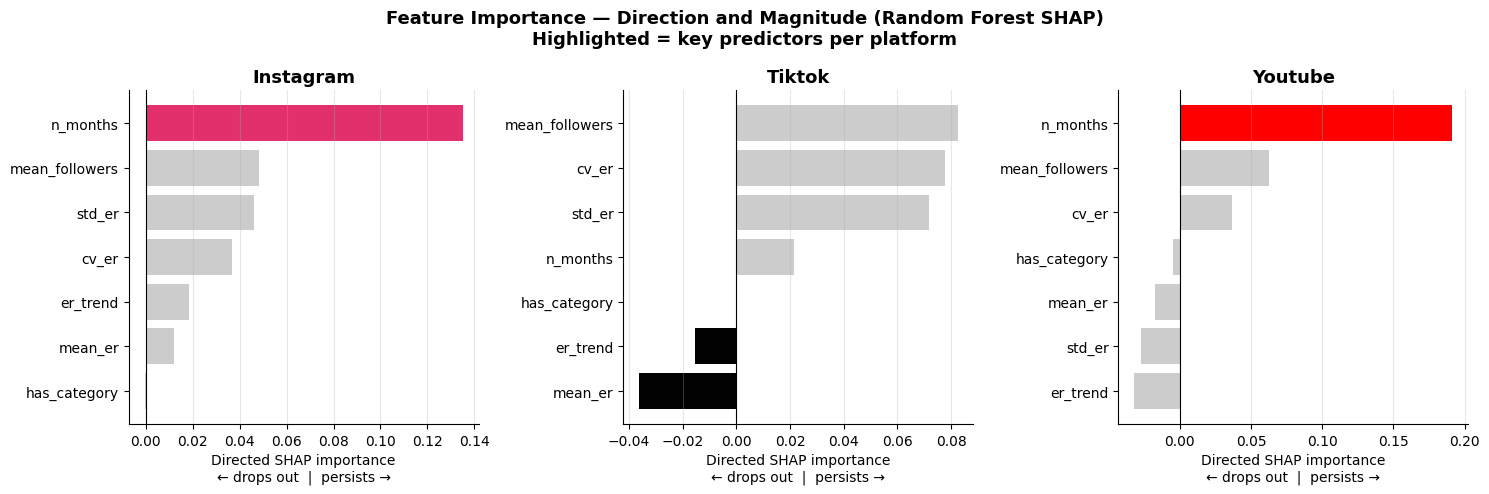

✅ Saved


In [13]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for ax, platform in zip(axes, PLATFORMS):
    sub      = features[features['platform'] == platform].copy()
    X        = sub[FEATURE_COLS].values
    y        = sub['persisted'].values
    scaler   = StandardScaler()
    X_scaled = scaler.fit_transform(X)

    best_rf = [r['best_params'] for r in results_tuned
               if r['platform'] == platform
               and r['model'] == 'Random Forest'][0]

    rf = RandomForestClassifier(
        class_weight='balanced', n_estimators=500,
        random_state=42, **best_rf)
    rf.fit(X_scaled, y)

    explainer   = shap.TreeExplainer(rf)
    shap_values = explainer.shap_values(X_scaled)
    sv = shap_values[1] if isinstance(shap_values, list) \
         else shap_values[:, :, 1]

    mean_abs     = np.abs(sv).mean(axis=0)
    correlations = [np.corrcoef(X_scaled[:, i], sv[:, i])[0, 1]
                    for i in range(len(FEATURE_COLS))]
    # handle NaN correlations
    correlations = [c if not np.isnan(c) else 0 for c in correlations]
    directed     = mean_abs * np.sign(correlations)

    shap_df = pd.DataFrame({
        'feature': FEATURE_COLS,
        'directed': directed
    }).sort_values('directed', ascending=True)

    # Color: platform color for negative, gray for positive
    if platform == 'tiktok':
        colors_bar = [
            COLORS[platform] if v < 0 else '#CCCCCC'
            for v in shap_df['directed']
        ]
    else:
        colors_bar = [
            COLORS[platform] if f == 'n_months' else '#CCCCCC'
            for f in shap_df['feature']
        ]

    ax.barh(shap_df['feature'], shap_df['directed'],
            color=colors_bar, edgecolor='none')
    ax.axvline(0, color='black', linewidth=0.8)

    ax.set_title(platform.capitalize(), fontweight='bold', fontsize=13)
    ax.set_xlabel('Directed SHAP importance\n← drops out  |  persists →')
    ax.grid(axis='x', alpha=0.3)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

fig.suptitle(
    'Feature Importance — Direction and Magnitude (Random Forest SHAP)\n'
    'Highlighted = key predictors per platform',
    fontweight='bold', fontsize=13
)
plt.tight_layout()
plt.savefig(OUT_PATH / 'shap_focused.png', bbox_inches='tight', dpi=150)
plt.show()
print("✅ Saved")

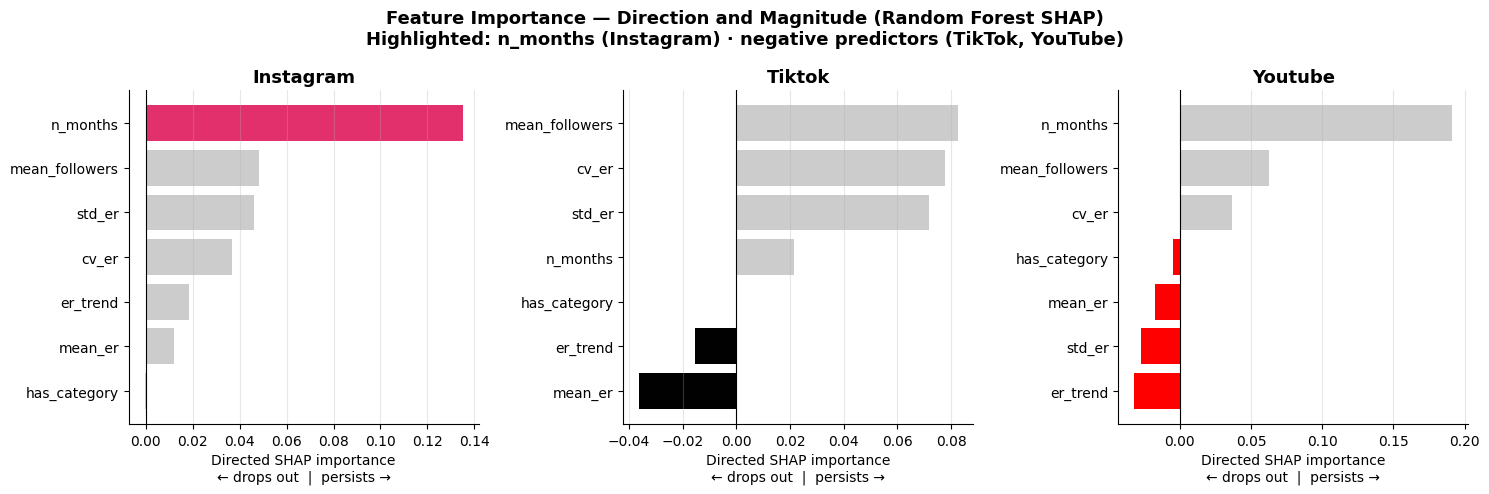

✅ Saved


In [14]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for ax, platform in zip(axes, PLATFORMS):
    sub      = features[features['platform'] == platform].copy()
    X        = sub[FEATURE_COLS].values
    y        = sub['persisted'].values
    scaler   = StandardScaler()
    X_scaled = scaler.fit_transform(X)

    best_rf = [r['best_params'] for r in results_tuned
               if r['platform'] == platform
               and r['model'] == 'Random Forest'][0]

    rf = RandomForestClassifier(
        class_weight='balanced', n_estimators=500,
        random_state=42, **best_rf)
    rf.fit(X_scaled, y)

    explainer   = shap.TreeExplainer(rf)
    shap_values = explainer.shap_values(X_scaled)
    sv = shap_values[1] if isinstance(shap_values, list) \
         else shap_values[:, :, 1]

    mean_abs     = np.abs(sv).mean(axis=0)
    correlations = [np.corrcoef(X_scaled[:, i], sv[:, i])[0, 1]
                    for i in range(len(FEATURE_COLS))]
    correlations = [c if not np.isnan(c) else 0 for c in correlations]
    directed     = mean_abs * np.sign(correlations)

    shap_df = pd.DataFrame({
        'feature': FEATURE_COLS,
        'directed': directed
    }).sort_values('directed', ascending=True)

    # Instagram: highlight n_months positive only
    # TikTok + YouTube: highlight all negative features
    if platform == 'instagram':
        colors_bar = [
            COLORS[platform] if f == 'n_months' else '#CCCCCC'
            for f in shap_df['feature']
        ]
    else:
        colors_bar = [
            COLORS[platform] if v < 0 else '#CCCCCC'
            for v in shap_df['directed']
        ]

    ax.barh(shap_df['feature'], shap_df['directed'],
            color=colors_bar, edgecolor='none')
    ax.axvline(0, color='black', linewidth=0.8)
    ax.set_title(platform.capitalize(), fontweight='bold', fontsize=13)
    ax.set_xlabel('Directed SHAP importance\n← drops out  |  persists →')
    ax.grid(axis='x', alpha=0.3)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

fig.suptitle(
    'Feature Importance — Direction and Magnitude (Random Forest SHAP)\n'
    'Highlighted: n_months (Instagram) · negative predictors (TikTok, YouTube)',
    fontweight='bold', fontsize=13
)
plt.tight_layout()
plt.savefig(OUT_PATH / 'shap_focused.png', bbox_inches='tight', dpi=150)
plt.show()
print("✅ Saved")

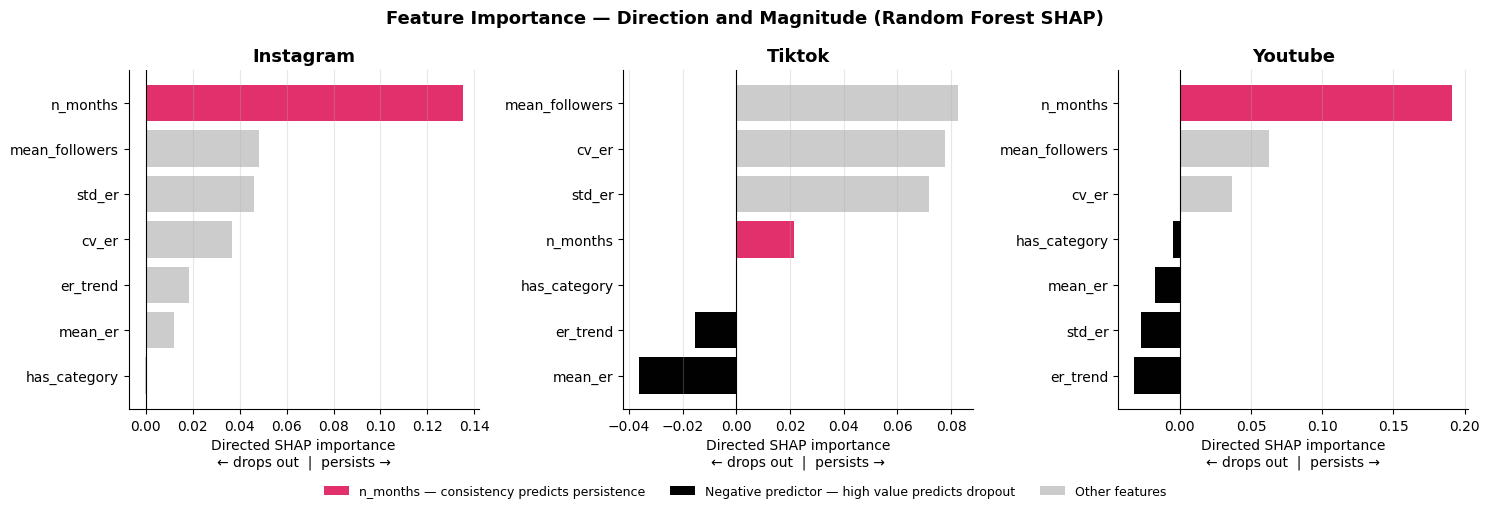

✅ Saved


In [15]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

HIGHLIGHT_POS = '#E1306C'  # red — n_months positive
HIGHLIGHT_NEG = '#010101'  # black — negative predictors
NEUTRAL       = '#CCCCCC'  # gray — everything else

for ax, platform in zip(axes, PLATFORMS):
    sub      = features[features['platform'] == platform].copy()
    X        = sub[FEATURE_COLS].values
    y        = sub['persisted'].values
    scaler   = StandardScaler()
    X_scaled = scaler.fit_transform(X)

    best_rf = [r['best_params'] for r in results_tuned
               if r['platform'] == platform
               and r['model'] == 'Random Forest'][0]

    rf = RandomForestClassifier(
        class_weight='balanced', n_estimators=500,
        random_state=42, **best_rf)
    rf.fit(X_scaled, y)

    explainer   = shap.TreeExplainer(rf)
    shap_values = explainer.shap_values(X_scaled)
    sv = shap_values[1] if isinstance(shap_values, list) \
         else shap_values[:, :, 1]

    mean_abs     = np.abs(sv).mean(axis=0)
    correlations = [np.corrcoef(X_scaled[:, i], sv[:, i])[0, 1]
                    for i in range(len(FEATURE_COLS))]
    correlations = [c if not np.isnan(c) else 0 for c in correlations]
    directed     = mean_abs * np.sign(correlations)

    shap_df = pd.DataFrame({
        'feature': FEATURE_COLS,
        'directed': directed
    }).sort_values('directed', ascending=True)

    if platform == 'instagram':
        # n_months red, everything else gray
        colors_bar = [
            HIGHLIGHT_POS if f == 'n_months' else NEUTRAL
            for f in shap_df['feature']
        ]
    else:
        # n_months red, negative values black, everything else gray
        colors_bar = []
        for f, v in zip(shap_df['feature'], shap_df['directed']):
            if f == 'n_months':
                colors_bar.append(HIGHLIGHT_POS)
            elif v < 0:
                colors_bar.append(HIGHLIGHT_NEG)
            else:
                colors_bar.append(NEUTRAL)

    ax.barh(shap_df['feature'], shap_df['directed'],
            color=colors_bar, edgecolor='none')
    ax.axvline(0, color='black', linewidth=0.8)
    ax.set_title(platform.capitalize(), fontweight='bold', fontsize=13)
    ax.set_xlabel('Directed SHAP importance\n← drops out  |  persists →')
    ax.grid(axis='x', alpha=0.3)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

# Legend
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor=HIGHLIGHT_POS, label='n_months — consistency predicts persistence'),
    Patch(facecolor=HIGHLIGHT_NEG, label='Negative predictor — high value predicts dropout'),
    Patch(facecolor=NEUTRAL,       label='Other features')
]
fig.legend(handles=legend_elements, loc='lower center',
           ncol=3, fontsize=9, frameon=False,
           bbox_to_anchor=(0.5, -0.02))

fig.suptitle(
    'Feature Importance — Direction and Magnitude (Random Forest SHAP)',
    fontweight='bold', fontsize=13
)
plt.tight_layout()
plt.subplots_adjust(bottom=0.18)
plt.savefig(OUT_PATH / 'shap_focused.png', bbox_inches='tight', dpi=150)
plt.show()
print("✅ Saved")

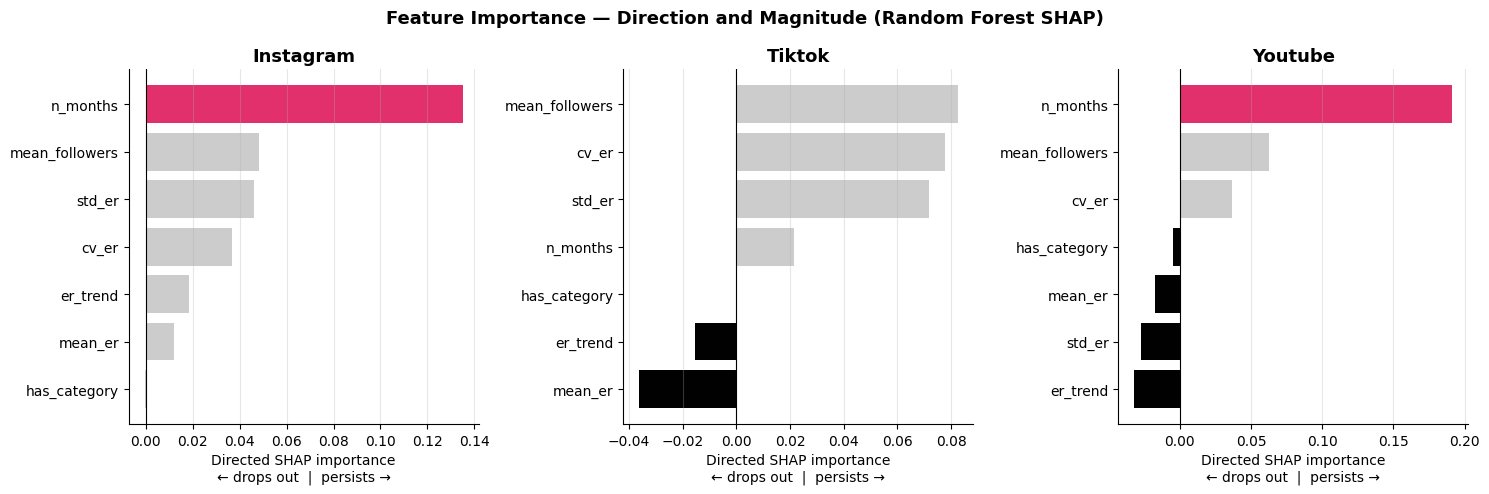

✅ Saved


In [16]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

HIGHLIGHT_POS = '#E1306C'  # red — n_months
HIGHLIGHT_NEG = '#010101'  # black — negative predictors
NEUTRAL       = '#CCCCCC'  # gray

for ax, platform in zip(axes, PLATFORMS):
    sub      = features[features['platform'] == platform].copy()
    X        = sub[FEATURE_COLS].values
    y        = sub['persisted'].values
    scaler   = StandardScaler()
    X_scaled = scaler.fit_transform(X)

    best_rf = [r['best_params'] for r in results_tuned
               if r['platform'] == platform
               and r['model'] == 'Random Forest'][0]

    rf = RandomForestClassifier(
        class_weight='balanced', n_estimators=500,
        random_state=42, **best_rf)
    rf.fit(X_scaled, y)

    explainer   = shap.TreeExplainer(rf)
    shap_values = explainer.shap_values(X_scaled)
    sv = shap_values[1] if isinstance(shap_values, list) \
         else shap_values[:, :, 1]

    mean_abs     = np.abs(sv).mean(axis=0)
    correlations = [np.corrcoef(X_scaled[:, i], sv[:, i])[0, 1]
                    for i in range(len(FEATURE_COLS))]
    correlations = [c if not np.isnan(c) else 0 for c in correlations]
    directed     = mean_abs * np.sign(correlations)

    shap_df = pd.DataFrame({
        'feature': FEATURE_COLS,
        'directed': directed
    }).sort_values('directed', ascending=True)

    if platform == 'instagram':
        colors_bar = [
            HIGHLIGHT_POS if f == 'n_months' else NEUTRAL
            for f in shap_df['feature']
        ]
    elif platform == 'youtube':
        colors_bar = [
            HIGHLIGHT_POS if f == 'n_months' else
            HIGHLIGHT_NEG if v < 0 else NEUTRAL
            for f, v in zip(shap_df['feature'], shap_df['directed'])
        ]
    else:  # tiktok
        colors_bar = [
            HIGHLIGHT_NEG if v < 0 else NEUTRAL
            for v in shap_df['directed']
        ]

    ax.barh(shap_df['feature'], shap_df['directed'],
            color=colors_bar, edgecolor='none')
    ax.axvline(0, color='black', linewidth=0.8)
    ax.set_title(platform.capitalize(), fontweight='bold', fontsize=13)
    ax.set_xlabel('Directed SHAP importance\n← drops out  |  persists →')
    ax.grid(axis='x', alpha=0.3)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

fig.suptitle(
    'Feature Importance — Direction and Magnitude (Random Forest SHAP)',
    fontweight='bold', fontsize=13
)
plt.tight_layout()
plt.savefig(OUT_PATH / 'shap_focused.png', bbox_inches='tight', dpi=150)
plt.show()
print("✅ Saved")

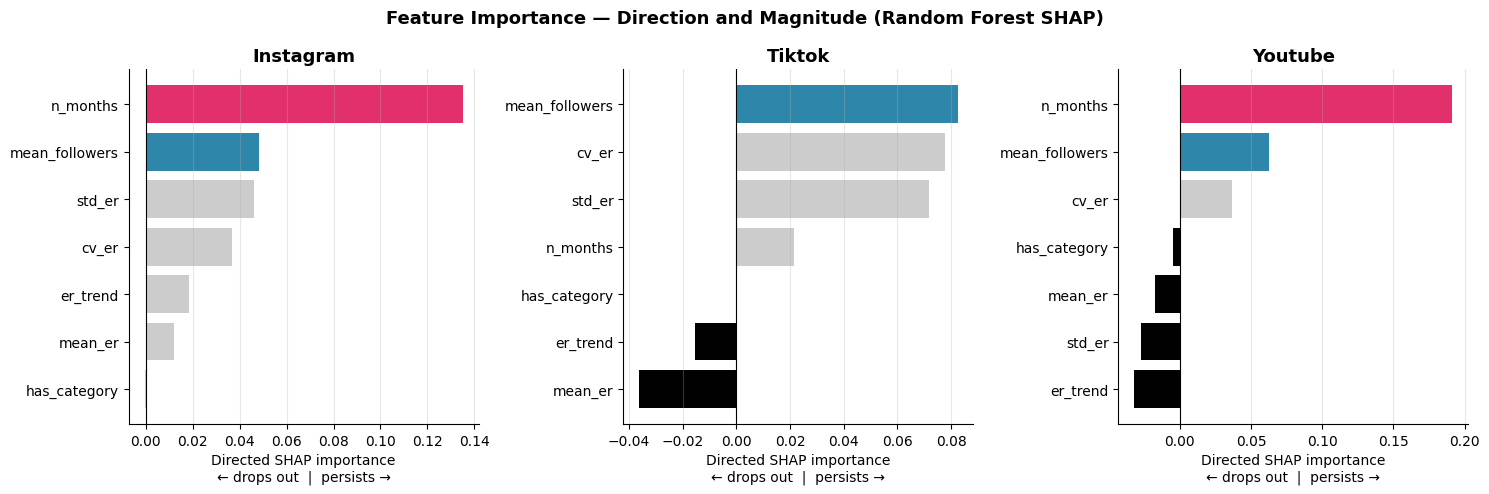

✅ Saved


In [17]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

HIGHLIGHT_POS  = '#E1306C'  # red — n_months
HIGHLIGHT_NEG  = '#010101'  # black — negative predictors
HIGHLIGHT_FOLL = '#2E86AB'  # blue — mean_followers
NEUTRAL        = '#CCCCCC'  # gray

for ax, platform in zip(axes, PLATFORMS):
    sub      = features[features['platform'] == platform].copy()
    X        = sub[FEATURE_COLS].values
    y        = sub['persisted'].values
    scaler   = StandardScaler()
    X_scaled = scaler.fit_transform(X)

    best_rf = [r['best_params'] for r in results_tuned
               if r['platform'] == platform
               and r['model'] == 'Random Forest'][0]

    rf = RandomForestClassifier(
        class_weight='balanced', n_estimators=500,
        random_state=42, **best_rf)
    rf.fit(X_scaled, y)

    explainer   = shap.TreeExplainer(rf)
    shap_values = explainer.shap_values(X_scaled)
    sv = shap_values[1] if isinstance(shap_values, list) \
         else shap_values[:, :, 1]

    mean_abs     = np.abs(sv).mean(axis=0)
    correlations = [np.corrcoef(X_scaled[:, i], sv[:, i])[0, 1]
                    for i in range(len(FEATURE_COLS))]
    correlations = [c if not np.isnan(c) else 0 for c in correlations]
    directed     = mean_abs * np.sign(correlations)

    shap_df = pd.DataFrame({
        'feature': FEATURE_COLS,
        'directed': directed
    }).sort_values('directed', ascending=True)

    def get_color(f, v, platform):
        if f == 'n_months' and platform != 'tiktok':
            return HIGHLIGHT_POS
        if f == 'mean_followers':
            return HIGHLIGHT_FOLL
        if v < 0 and platform in ['tiktok', 'youtube']:
            return HIGHLIGHT_NEG
        return NEUTRAL

    colors_bar = [
        get_color(f, v, platform)
        for f, v in zip(shap_df['feature'], shap_df['directed'])
    ]

    ax.barh(shap_df['feature'], shap_df['directed'],
            color=colors_bar, edgecolor='none')
    ax.axvline(0, color='black', linewidth=0.8)
    ax.set_title(platform.capitalize(), fontweight='bold', fontsize=13)
    ax.set_xlabel('Directed SHAP importance\n← drops out  |  persists →')
    ax.grid(axis='x', alpha=0.3)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

fig.suptitle(
    'Feature Importance — Direction and Magnitude (Random Forest SHAP)',
    fontweight='bold', fontsize=13
)
plt.tight_layout()
plt.savefig(OUT_PATH / 'shap_focused.png', bbox_inches='tight', dpi=150)
plt.show()
print("✅ Saved")